Prepare the data. I have 8 input features and 21 target outputs.

In [2]:
import pandas as pd

# load dataset
data = pd.read_csv('data/raw_data.csv')
print(data.info())

# print header labels
labels = data.columns.tolist()
x_labels = labels[0:8]
y_labels = labels[8:]
print("xlabels:", x_labels)
print("ylabels:", y_labels)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2813 entries, 0 to 2812
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ε11     2813 non-null   float64
 1   ε22     2813 non-null   float64
 2   ε12     2813 non-null   float64
 3   ɣ13     2813 non-null   float64
 4   ɣ23     2813 non-null   float64
 5   κ11     2813 non-null   float64
 6   κ22     2813 non-null   float64
 7   κ12     2813 non-null   float64
 8   A11     2813 non-null   float64
 9   A22     2813 non-null   float64
 10  A33     2813 non-null   float64
 11  A23     2813 non-null   float64
 12  A13     2813 non-null   float64
 13  A12     2813 non-null   float64
 14  B11     2813 non-null   float64
 15  B22     2813 non-null   float64
 16  B33     2813 non-null   float64
 17  B23     2813 non-null   float64
 18  B13     2813 non-null   float64
 19  B12     2813 non-null   float64
 20  D11     2813 non-null   float64
 21  D22     2813 non-null   float64
 22  

In [3]:
# extract features and targets
x: pd.DataFrame = data[x_labels]
y: pd.DataFrame = data[y_labels]

# remove non-zero transverse shear strain , 'ɣ13', 'ɣ23'
idx = (x.iloc[:,3] == 0.0) & (x.iloc[:,4] == 0.0)
x = x.loc[idx]
y = y.loc[idx]

# removing transverse shear strain columns
x = x.drop(columns=['ɣ13', 'ɣ23'])
y = y.drop(columns=["K11", "K22", "K12"])

# removing data offset
x.iloc[:, 0] -= 1  # ε11 has offset 1
x.iloc[:, 1] -= 1  # ε22 has offset 1


# save processed data to csv
x.to_csv('data/x_data.csv', index=False)
y.to_csv('data/y_data.csv', index=False)

# print header labels
x_labels = x.columns.tolist()
y_labels = y.columns.tolist()
print("xlabels:", x_labels)
print("ylabels:", y_labels)

# convert data to nd.arrays
x = x.values
y = y.values
print("x shape:", x.shape)
print("y shape:", y.shape)


xlabels: ['ε11', 'ε22', 'ε12', 'κ11', 'κ22', 'κ12']
ylabels: ['A11', 'A22', 'A33', 'A23', 'A13', 'A12', 'B11', 'B22', 'B33', 'B23', 'B13', 'B12 ', 'D11', 'D22', 'D33', 'D23', 'D13', 'D12']
x shape: (1358, 6)
y shape: (1358, 18)


In [41]:
import torch

# run on GPU if available
global device
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

In [42]:
from torch import Tensor

def construct_sub_matrix(array):
    """Constructs a symmetric matrix from an array of unique terms.

    Args:
        array (torch.Tensor): unique terms in the symmetric matrix

    Returns:
        torch.Tensor: assembled sub matrix
    """

    # fill in the lower triangle of the matrix   
    matrix = torch.zeros((3, 3), device=device)
    matrix[2, 2] = array[2]  # 33
    matrix[2, 1] = array[3]  # 23
    matrix[2, 0] = array[4]  # 13
    matrix[1, 0] = array[5]  # 12 
    matrix[0, 0] = array[0]  # 11
    matrix[1, 1] = array[1]  # 22
    # mirror lower triangle to upper triangle
    matrix: Tensor = matrix + matrix.T - torch.diag(matrix.diagonal())

    return matrix

def construct_full_matrix(array):

    A: Tensor = construct_sub_matrix(array=array[0:6])
    B: Tensor = construct_sub_matrix(array=array[6:12])
    D: Tensor = construct_sub_matrix(array=array[12:18])

    matrix: Tensor = torch.zeros((6, 6), device=device)    
    matrix[0:3, 0:3] = A
    matrix[0:3, 3:6] = B
    matrix[3:6, 0:3] = B
    matrix[3:6, 3:6] = D

    
    return matrix

# convert data to torch tensors
print(y[0])
matrix = construct_full_matrix(torch.tensor(y[0], device=device))
print("A:\n", matrix[0:3, 0:3])
print("B:\n", matrix[0:3, 3:6])
print("D:\n", matrix[3:6, 3:6])


[ 3.92922916e+01  3.47253911e+02  8.59728303e+00  1.97394770e-02
  1.82106330e-02  2.09769623e+01  4.20000000e-05 -2.10000000e-05
 -4.14000000e-06  2.02000000e-05  2.58000000e-05  6.79000000e-05
  1.26507750e+03  4.57065988e+03  4.11240461e+02  5.05000000e-05
  9.61000000e-05  7.23216636e+02]
A:
 tensor([[3.9292e+01, 2.0977e+01, 1.8211e-02],
        [2.0977e+01, 3.4725e+02, 1.9739e-02],
        [1.8211e-02, 1.9739e-02, 8.5973e+00]], device='cuda:0')
B:
 tensor([[ 4.2000e-05,  6.7900e-05,  2.5800e-05],
        [ 6.7900e-05, -2.1000e-05,  2.0200e-05],
        [ 2.5800e-05,  2.0200e-05, -4.1400e-06]], device='cuda:0')
D:
 tensor([[1.2651e+03, 7.2322e+02, 9.6100e-05],
        [7.2322e+02, 4.5707e+03, 5.0500e-05],
        [9.6100e-05, 5.0500e-05, 4.1124e+02]], device='cuda:0')


In [43]:
# z score normalization
x_mean = x.mean(axis=0)
x_std = x.std(axis=0)
y_mean = y.mean(axis=0)
y_std = y.std(axis=0)
x_normalized = (x - x_mean) / x_std
y_normalized = (y - y_mean) / y_std

# convert to torch tensors and move to device
x_tensor = torch.tensor(x_normalized, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_normalized, dtype=torch.float32).to(device)


Shuffle and split the dataset by 80, 10 and 10 percent for training, cross-validation and testing

In [44]:

# shuffle and split dataset
torch.manual_seed(42)
shuffle_indices = torch.randperm(x_tensor.shape[0])
x_shuffled = x_tensor[shuffle_indices]
y_shuffled = y_tensor[shuffle_indices]
    
n1 = int(0.8 * x_tensor.shape[0])  # 80%
n2 = int(0.9 * x_tensor.shape[0])  # 90%

Xtr, Ytr = x_shuffled[:n1], y_shuffled[:n1]       # 80% training
Xdev, Ydev = x_shuffled[n1:n2], y_shuffled[n1:n2] # 10% validation
Xte, Yte = x_shuffled[n2:], y_shuffled[n2:]       # 10% test

print(f'Training set: {Xtr.shape}, {Ytr.shape}')
print(f'Validation set: {Xdev.shape}, {Ydev.shape}')
print(f'Test set: {Xte.shape}, {Yte.shape}')

Training set: torch.Size([1086, 6]), torch.Size([1086, 18])
Validation set: torch.Size([136, 6]), torch.Size([136, 18])
Test set: torch.Size([136, 6]), torch.Size([136, 18])


The MLP is defined by $A \rightarrow [B]\times C \rightarrow D$ where A is number of input features, B is number of neurons in each hidden layer, C is number of hidden layers and D is the number of output targets. Input layer and all hidden layer has ReLu activation and the output layer is linear.

In [45]:
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self, input_size, neurons_per_layer, num_hidden_layers, output_size):
        super(MLP, self).__init__()
        # input layer
        layers = [nn.Linear(input_size, neurons_per_layer)]
        # hidden layers + output layer
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))
        # output layer
        layers.append(nn.Linear(neurons_per_layer, output_size))
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        # pass through hidden layers with ReLU activation
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        x = self.layers[-1](x)
        return x
    
# model parameters
input_size = Xtr.shape[1]      # number of input features
neurons_per_layer = 180         # number of neurons in each hidden layer
num_hidden_layers = 6          # number of hidden layers
output_size = Ytr.shape[1]     # number of output targets

# instantiate model and move to device
MLP_model = MLP(input_size, neurons_per_layer, num_hidden_layers, output_size).to(device)    
print(MLP_model)

MLP(
  (layers): ModuleList(
    (0): Linear(in_features=6, out_features=180, bias=True)
    (1-6): 6 x Linear(in_features=180, out_features=180, bias=True)
    (7): Linear(in_features=180, out_features=18, bias=True)
  )
)


In [46]:
def train_model(model, Xtr, Ytr, Xdev, Ydev, epochs=10000, learning_rate=0.0001, weight_decay=1e-4):
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()  # Mean Square Error
    def L2_reg(): return sum(torch.sum(p ** 2) for n, p in model.named_parameters() if 'weight' in n)
    loss_values = []
    
    for epoch in range(epochs):
        outputs = model(Xtr)
        loss = criterion(outputs, Ytr) + weight_decay*L2_reg()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 100 == 0:
            model.eval()
            with torch.no_grad():
                tr_loss = criterion(model(Xtr), Ytr)
                val_loss = criterion(model(Xdev), Ydev)
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {tr_loss.item():.4f}, Val Loss: {val_loss.item():.4f}')
            loss_values.append([epoch + 1, tr_loss.item(), val_loss.item()])
            model.train()
    
    return torch.tensor(loss_values, dtype=torch.float32)

# helper to (re)initialize model parameters
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# train the model
model_data = {}
for model in [MLP_model]:
    print(f'Training model: {model.__class__.__name__}')
    # weight initialization
    model.apply(init_weights)
    loss_curve = train_model(model, Xtr, Ytr, Xdev, Ydev, epochs=10000, learning_rate=1e-3, weight_decay=1e-3)
    model_data[model.__class__.__name__] = loss_curve




Training model: MLP
Epoch [100/10000], Loss: 0.1232, Val Loss: 0.1691
Epoch [200/10000], Loss: 0.0883, Val Loss: 0.1196
Epoch [300/10000], Loss: 0.0799, Val Loss: 0.1088
Epoch [400/10000], Loss: 0.0757, Val Loss: 0.0954
Epoch [500/10000], Loss: 0.0727, Val Loss: 0.0955
Epoch [600/10000], Loss: 0.0699, Val Loss: 0.0905
Epoch [700/10000], Loss: 0.0701, Val Loss: 0.0926
Epoch [800/10000], Loss: 0.0672, Val Loss: 0.0870
Epoch [900/10000], Loss: 0.0750, Val Loss: 0.0935
Epoch [1000/10000], Loss: 0.0731, Val Loss: 0.0954
Epoch [1100/10000], Loss: 0.0645, Val Loss: 0.0858
Epoch [1200/10000], Loss: 0.0653, Val Loss: 0.0854
Epoch [1300/10000], Loss: 0.0636, Val Loss: 0.0847
Epoch [1400/10000], Loss: 0.0649, Val Loss: 0.0881
Epoch [1500/10000], Loss: 0.0679, Val Loss: 0.0883
Epoch [1600/10000], Loss: 0.0643, Val Loss: 0.0870
Epoch [1700/10000], Loss: 0.0780, Val Loss: 0.0945
Epoch [1800/10000], Loss: 0.0666, Val Loss: 0.0897
Epoch [1900/10000], Loss: 0.0789, Val Loss: 0.1052
Epoch [2000/10000], 

Evaluating model: MLP
Test Loss: 0.1055


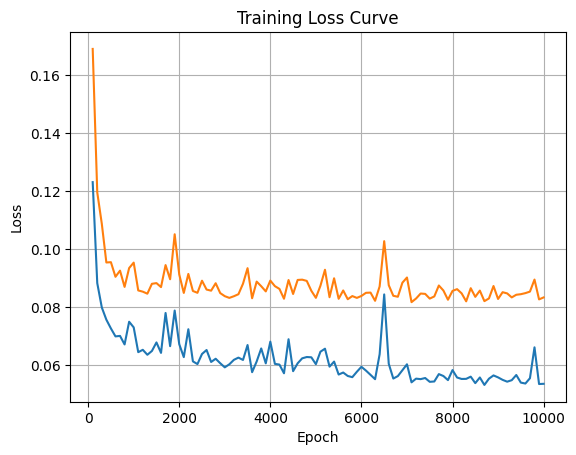

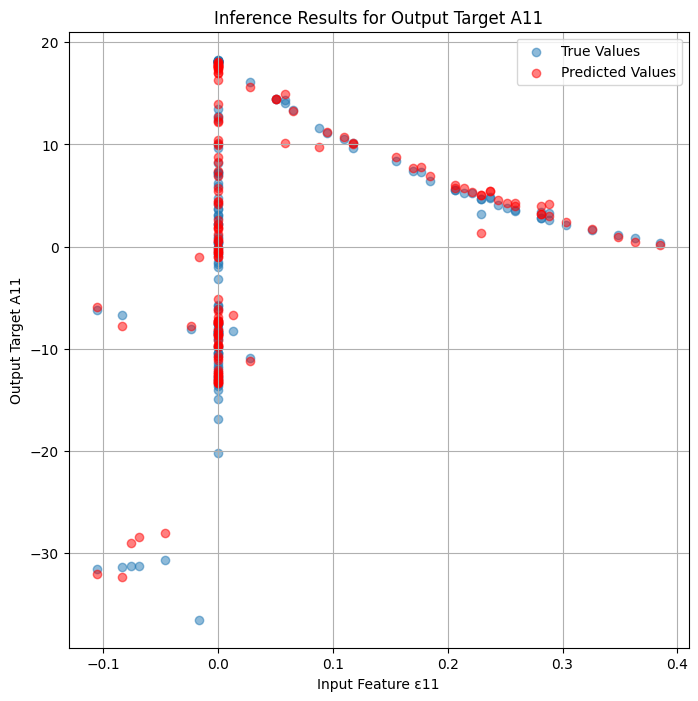

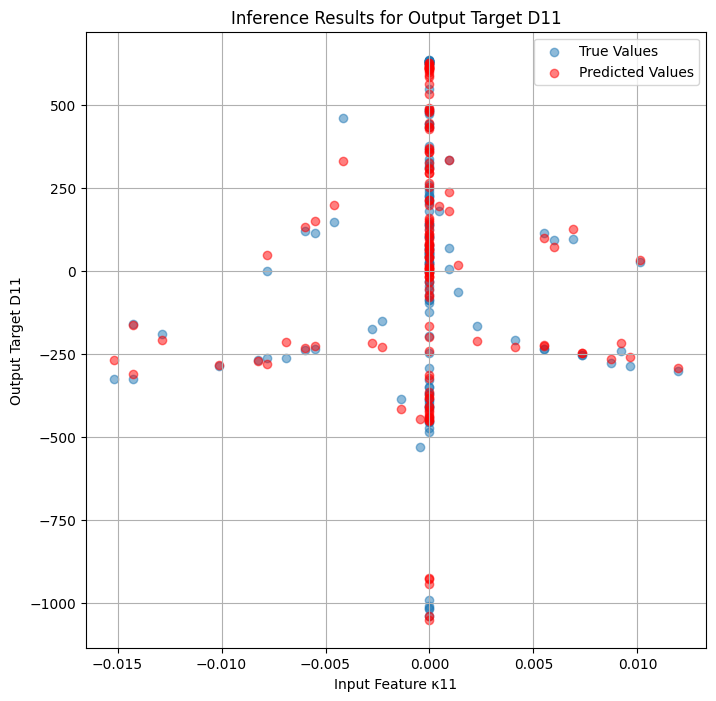

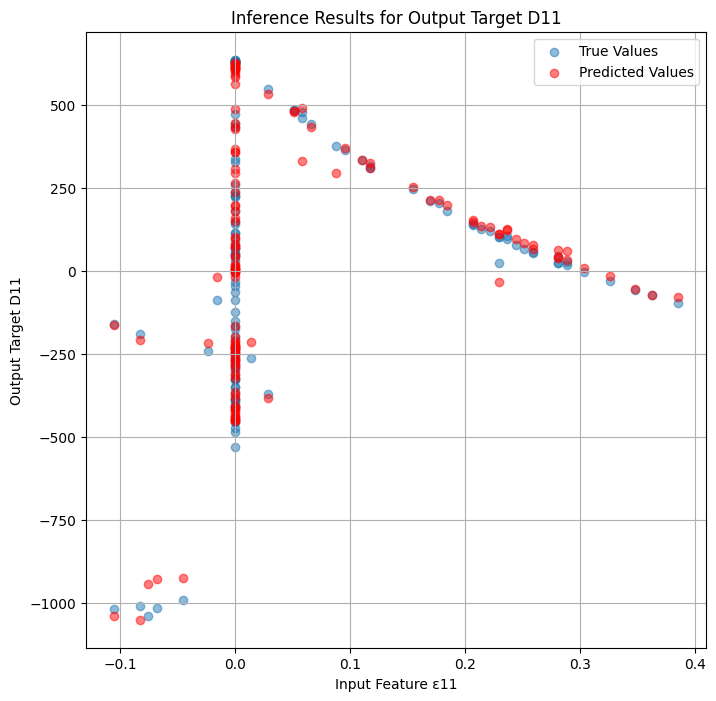

In [48]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_loss_curve(loss_values):
    plt.plot(loss_values[:, 0], loss_values[:, 1], label='Training Loss')
    plt.plot(loss_values[:, 0], loss_values[:, 2], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.grid()
    plt.show()

def plot_inference_results(xy_pred, xy_true, x_label, y_label, title='Inference', bool_line=False):
    plt.figure(figsize=(8, 8))
    plt.scatter(xy_true[0], xy_true[1], alpha=0.5, label='True Values')
    if bool_line:
        plt.plot(xy_pred[0], xy_pred[1], 'r--')
    else:
        plt.scatter(xy_pred[0], xy_pred[1], color='red', alpha=0.5, label='Predicted Values')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid()
    plt.legend()
    plt.show()

# evaluate the model on test set
def evaluate_model(model, X, Y):
    with torch.no_grad():
        test_outputs = model(X)
        criterion = nn.L1Loss()
        test_loss = criterion(test_outputs, Y)
    print(f'Test Loss: {test_loss.item():.4f}')

def plot_ABD_terms(x_index, y_index, model, Xte, Yte, bool_line=False):
    with torch.no_grad():
        if bool_line:
            x_test = torch.zeros((50, Xte.shape[1]), dtype=torch.float32).to(device)
            x_test[:, x_index] = torch.linspace(Xte[:, x_index].min(), Xte[:, x_index].max(), 50)
        else:
            x_test = Xte
        y_test = model(x_test)

    # scale back to prediction 
    x_test_scaled = x_test[:, x_index].cpu().numpy() * x_std[x_index] + x_mean[x_index]
    y_test_scaled = y_test[:, y_index].cpu().numpy() * y_std[y_index]

    # scale back to true values
    x_true = Xte[:, x_index].cpu().numpy() * x_std[x_index] + x_mean[x_index]
    y_true = Yte[:, y_index].cpu().numpy() * y_std[y_index]

    # plot inference results
    plot_inference_results(
        (x_test_scaled, y_test_scaled),
        (x_true, y_true),
        x_label=f'Input Feature {x_labels[x_index]}',
        y_label=f'Output Target {y_labels[y_index]}',
        title=f'Inference Results for Output Target {y_labels[y_index]}',
        bool_line=bool_line
    )


# model testing and visualization
# xlabels: ['ε11', 'ε22', 'ε12', 'κ11', 'κ22', 'κ12']
# ylabels: ['A11', 'A22', 'A33', 'A23', 'A13', 'A12', 'B11', 'B22', 'B33', 'B23', 'B13', 'B12 ', 'D11', 'D22', 'D33', 'D23', 'D13', 'D12']
for model_name in model_data.keys():
    print(f'Evaluating model: {model_name}')
    evaluate_model(model, Xte, Yte)
    plot_loss_curve(model_data[model_name])

    # e11 vs A11 plot
    x_index = 0
    y_index = 0
    plot_ABD_terms(x_index, y_index, model, Xte, Yte)

    # k11 vs D11 plot
    x_index = 3
    y_index = 12
    plot_ABD_terms(x_index, y_index, model, Xte, Yte)

    # k11 vs D11 plot
    x_index = 0
    y_index = 12
    plot_ABD_terms(x_index, y_index, model, Xte, Yte)